In [13]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
import statsmodels.api as sm
import matplotlib.pyplot as plt
import gc
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# FEATURE SETS
# ============================================================

VALUE    = ['bm','bm_ia','cfp','cfp_ia','ep','sp','dy']

QUALITY  = ['roaq','roeq','gma','operprof',
            'acc','absacc','pctacc',
            'tb','cashdebt','stdacc',
            'agr','egr','lgr','invest',
            'lev','ms','nincr']

MOMENTUM = ['mom1m','mom6m','mom12m','mom36m','chmom','indmom']

FEATURE_SETS = {
    'A_Value':           VALUE,
    'B_ValueQuality':    VALUE + QUALITY,
    'C_ValueQualityMom': VALUE + QUALITY + MOMENTUM,
}

TARGET = 'ret'

# Optimal settings per model
COVERAGE = {
    'A_Value':           0.0,
    'B_ValueQuality':    0.5,   # optimal from tests
    'C_ValueQualityMom': 0.6,
}

TURNOVER_BUFFER = {
    'A_Value':           0,
    'B_ValueQuality':    2,     # optimal from tests
    'C_ValueQualityMom': 2,
}

# ============================================================
# STEP 1: LOAD DATA
# ============================================================

print("Loading Kelly dataset...")

all_features = VALUE + QUALITY + MOMENTUM
load_cols    = ['permno','date',TARGET] + all_features

chunks = []
for chunk in pd.read_csv('kelly_final.csv',
                          usecols=lambda c: c in load_cols,
                          chunksize=500000,
                          parse_dates=['date']):
    chunks.append(chunk)

kelly = pd.concat(chunks, ignore_index=True)
kelly = kelly.sort_values(['permno','date']).reset_index(drop=True)
del chunks
gc.collect()

print(f"Kelly rows: {len(kelly):,}  |  {kelly['date'].min()} to {kelly['date'].max()}")

print("\nLoading extension dataset...")
ext = pd.read_csv('features_2022_2024.csv', parse_dates=['date'])
ext = ext.sort_values(['permno','date']).reset_index(drop=True)
print(f"Extension rows: {len(ext):,}  |  {ext['date'].min()} to {ext['date'].max()}")

# ============================================================
# STEP 2: COVERAGE FILTER
# ============================================================

def apply_coverage_filter(df, feature_cols, min_coverage=0.0):
    if min_coverage <= 0:
        return df
    df = df.copy()
    quality_cols = [c for c in feature_cols if c not in VALUE + MOMENTUM]
    if not quality_cols:
        return df
    coverage = df[quality_cols].notna().mean(axis=1)
    mask     = coverage >= min_coverage
    df_out   = df[mask].copy()
    pct      = 1 - len(df_out) / len(df)
    print(f"  Coverage filter >={min_coverage:.0%}: "
          f"{len(df):,} → {len(df_out):,} ({pct:.1%} dropped)")
    return df_out

# ============================================================
# STEP 3: RANK NORMALIZATION
# ============================================================

def rank_normalize(df, feature_cols):
    df = df.copy()

    def cs_rank(x):
        r = x.rank(method='average')
        if len(r) <= 1:
            return r * 0
        return (r - 1) / (len(r) - 1) * 2 - 1

    df[feature_cols] = df.groupby('date')[feature_cols].transform(
        lambda x: x.fillna(x.median())
    )
    df[feature_cols] = df[feature_cols].fillna(0)
    df[feature_cols] = df.groupby('date')[feature_cols].transform(cs_rank)
    return df

# ============================================================
# STEP 4: FF5 FACTORS
# ============================================================

def get_ff5():
    import requests, zipfile, io
    url = ("https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/"
           "ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip")
    print("Downloading FF5 factors...")
    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    with z.open(z.namelist()[0]) as f:
        raw = f.read().decode('utf-8')
    lines = raw.split('\n')
    start = 0
    for i, line in enumerate(lines):
        stripped = line.strip()
        if (stripped and stripped[0].isdigit()
                and len(stripped.split(',')[0].strip()) == 6):
            start = i
            break
    from io import StringIO
    ff5 = pd.read_csv(
        StringIO('\n'.join(lines[start:])),
        header=None,
        names=['date','MKT','SMB','HML','RMW','CMA','RF'],
        on_bad_lines='skip'
    )
    ff5 = ff5[ff5['date'].astype(str).str.strip().str.len() == 6]
    ff5['date'] = pd.to_datetime(
        ff5['date'].astype(str).str.strip(), format='%Y%m'
    )
    ff5 = ff5.set_index('date')
    ff5 = ff5.apply(pd.to_numeric, errors='coerce') / 100
    ff5 = ff5.dropna()
    print(f"FF5 loaded: {ff5.index[0]} to {ff5.index[-1]}")
    return ff5

ff5       = get_ff5()
rf_series = ff5['RF']


Loading Kelly dataset...
Kelly rows: 3,895,198  |  1957-01-01 00:00:00 to 2021-12-01 00:00:00

Loading extension dataset...
Extension rows: 180,123  |  2022-01-01 00:00:00 to 2024-11-01 00:00:00
FF5 loaded: 1963-07-01 00:00:00 to 2026-02-01 00:00:00


In [14]:

# ============================================================
# STEP 5: PIOTROSKI F-SCORE (diagnostic only, filter=False)
# ============================================================

def compute_fscore(month_df):
    df    = month_df.copy()
    score = pd.Series(0, index=df.index)
    for col in ['roaq', 'cfp', 'nincr']:
        if col in df.columns:
            score += (df[col] > 0).astype(int)
    if 'acc'     in df.columns: score += (df['acc']     < 0).astype(int)
    if 'lev'     in df.columns: score += (df['lev']     < 0).astype(int)
    if 'cashdebt'in df.columns: score += (df['cashdebt']> 0).astype(int)
    if 'egr'     in df.columns: score += (df['egr']     < 0).astype(int)
    for col in ['gma', 'operprof']:
        if col in df.columns:
            score += (df[col] > 0).astype(int)
    return score


In [15]:

# ============================================================
# STEP 6: PORTFOLIO BUILDER
# ============================================================

def build_portfolio_with_costs(month_df, n_deciles, date,
                                prev_long, prev_short, tc,
                                turnover_buffer=0.0,
                                piotroski_filter=False,
                                piotroski_min=5,
                                piotroski_min_stocks=20):
    try:
        month_df = month_df.copy()
        month_df['decile'] = pd.qcut(
            month_df['pred'], n_deciles,
            labels=False, duplicates='drop'
        )
    except ValueError:
        return None

    actual_max = month_df['decile'].max()
    actual_min = month_df['decile'].min()

    if actual_max == actual_min or pd.isna(actual_max):
        return None

    long_df  = month_df[month_df['decile'] == actual_max].copy()
    short_df = month_df[month_df['decile'] == actual_min].copy()

    # Turnover buffer — carry incumbents that are still near top/bottom
    if turnover_buffer > 0 and len(prev_long) > 0:
        carry_long = month_df[
            (month_df['permno'].isin(prev_long)) &
            (month_df['decile'] >= actual_max - turnover_buffer)
        ]
        long_df = pd.concat([long_df, carry_long]).drop_duplicates('permno')
        carry_short = month_df[
            (month_df['permno'].isin(prev_short)) &
            (month_df['decile'] <= actual_min + turnover_buffer)
        ]
        short_df = pd.concat([short_df, carry_short]).drop_duplicates('permno')

    # F-score: always compute for diagnostics
    month_df['fscore'] = compute_fscore(month_df)
    long_df  = long_df.merge(month_df[['permno','fscore']], on='permno', how='left')
    short_df = short_df.merge(month_df[['permno','fscore']], on='permno', how='left')

    avg_fscore_long  = long_df['fscore'].mean()
    avg_fscore_short = short_df['fscore'].mean()

    # Piotroski hard filter (currently False for all models)
    if piotroski_filter:
        filtered = long_df[long_df['fscore'] >= piotroski_min]
        if len(filtered) >= piotroski_min_stocks:
            long_df = filtered

    if len(long_df) == 0:
        return None

    long_ret_gross  = long_df[TARGET].mean()
    short_ret_gross = short_df[TARGET].mean() if len(short_df) > 0 else 0

    curr_long  = set(long_df['permno'].values)
    curr_short = set(short_df['permno'].values)

    long_turnover  = (len(curr_long  - prev_long)  / len(curr_long))  if prev_long  else 1.0
    short_turnover = (len(curr_short - prev_short) / len(curr_short)) if prev_short else 1.0

    long_ret_net  = long_ret_gross  - long_turnover  * tc
    short_ret_net = short_ret_gross + short_turnover * tc
    ls_ret_net    = long_ret_net    - short_ret_net
    ls_ret_gross  = long_ret_gross  - short_ret_gross

    return {
        'date':             date,
        'long_ret':         long_ret_net,
        'short_ret':        short_ret_net,
        'ls_ret':           ls_ret_net,
        'ls_ret_gross':     ls_ret_gross,
        'long_turnover':    long_turnover,
        'short_turnover':   short_turnover,
        'avg_turnover':     (long_turnover + short_turnover) / 2,
        'n_long':           len(long_df),
        'n_short':          len(short_df),
        'mkt_ret':          month_df[TARGET].mean(),
        'avg_fscore_long':  avg_fscore_long,
        'avg_fscore_short': avg_fscore_short,
        'long_permnos':     curr_long,
        'short_permnos':    curr_short,
    }

# ============================================================
# STEP 7: TRAINING HELPERS
# ============================================================

def prepare_training_data(train_df, feature_cols, target_col='ret'):
    train       = train_df.dropna(subset=[target_col]).copy()
    X           = train[feature_cols].copy()
    y           = train[target_col].values
    col_medians = X.median()
    X           = X.fillna(col_medians).fillna(0).clip(-10, 10)
    X_vals      = X.values
    mask        = np.isfinite(X_vals).all(axis=1) & np.isfinite(y)
    return X_vals[mask], y[mask]

def predict_month(month_df, feature_cols, model):
    X_pred = (month_df[feature_cols]
              .fillna(month_df[feature_cols].median())
              .fillna(0)
              .clip(-10, 10)
              .values)
    return model.predict(X_pred)

def make_xgb(device):
    return XGBRegressor(
        n_estimators      = 500,
        learning_rate     = 0.01,
        max_depth         = 6,
        min_child_weight  = 20,
        subsample         = 0.5,
        colsample_bytree  = 0.5,
        reg_alpha         = 0.1,
        reg_lambda        = 0.1,
        random_state      = 42,
        verbosity         = 0,
        device            = device,
        tree_method       = 'hist',
    )

# ============================================================
# STEP 8: GPU CHECK
# ============================================================

try:
    test = XGBRegressor(device='cuda', n_estimators=10, verbosity=0)
    test.fit([[1,2],[3,4]], [1,0])
    print("CUDA confirmed — using GPU")
    DEVICE = 'cuda'
except Exception:
    print("No CUDA — using CPU")
    DEVICE = 'cpu'


CUDA confirmed — using GPU


In [ ]:

# ============================================================
# STEP 9: BACKTEST ENGINE
# ============================================================

def run_backtest(kelly_df, ext_df, feature_cols, model_name,
                 train_end        = '2005-12-01',
                 test_start       = '2006-01-01',
                 test_end         = '2021-12-01',
                 ext_start        = '2022-01-01',
                 ext_end          = '2024-11-01',
                 n_deciles        = 10,
                 transaction_cost = 0.0050,
                 min_coverage     = 0.0,
                 turnover_buffer  = 0.0,
                 piotroski_filter = False):

    print(f"\n{'='*60}")
    print(f"Model: {model_name} | Features: {len(feature_cols)}")
    print(f"Coverage: {min_coverage:.0%} | Buffer: {turnover_buffer}")
    print(f"Train: 1957–{train_end} | OOS: {test_start}–{test_end}")
    print(f"{'='*60}")

    kelly_filtered = apply_coverage_filter(kelly_df, feature_cols, min_coverage)
    ext_filtered   = apply_coverage_filter(ext_df,   feature_cols, min_coverage)

    print("Rank normalizing...")
    kelly_proc = rank_normalize(kelly_filtered, feature_cols)
    ext_proc   = rank_normalize(ext_filtered,   feature_cols)

    test_dates = sorted(kelly_proc[
        (kelly_proc['date'] >= test_start) &
        (kelly_proc['date'] <= test_end)
    ]['date'].unique())

    ext_dates = sorted(ext_proc[
        (ext_proc['date'] >= ext_start) &
        (ext_proc['date'] <= ext_end)
    ]['date'].unique())

    results            = []
    model              = None
    last_retrain_year  = None
    prev_long_permnos  = set()
    prev_short_permnos = set()

    # Pre-train
    print(f"\nPre-training on data before {test_start}...")
    pretrain     = kelly_proc[kelly_proc['date'] < test_start]
    X_pre, y_pre = prepare_training_data(pretrain, feature_cols)
    if len(y_pre) < 1000:
        raise ValueError(f"Only {len(y_pre)} obs before test_start")
    model = make_xgb(DEVICE)
    model.fit(X_pre, y_pre)
    last_retrain_year = pd.Timestamp(test_start).year - 1
    print(f"  Pre-trained on {len(y_pre):,} obs — model ready")

    # OOS loop
    print(f"\nRunning OOS ({len(test_dates)} months)...")
    for test_date in test_dates:
        current_year = test_date.year
        if current_year != last_retrain_year:
            train      = kelly_proc[kelly_proc['date'] < test_date]
            X_tr, y_tr = prepare_training_data(train, feature_cols)
            if len(y_tr) >= 1000:
                new_model = make_xgb(DEVICE)
                new_model.fit(X_tr, y_tr)
                model             = new_model
                last_retrain_year = current_year
                print(f"  [{test_date.strftime('%Y-%m')}] Retrained on {len(y_tr):,} obs")
            else:
                print(f"  [{test_date.strftime('%Y-%m')}] WARNING: {len(y_tr):,} obs — keeping prev model")

        month_df = kelly_proc[kelly_proc['date'] == test_date].copy()
        if len(month_df) < 20:
            continue
        month_df['pred'] = predict_month(month_df, feature_cols, model)

        result = build_portfolio_with_costs(
            month_df, n_deciles, test_date,
            prev_long_permnos, prev_short_permnos,
            transaction_cost,
            turnover_buffer=turnover_buffer,
            piotroski_filter=piotroski_filter
        )
        if result:
            prev_long_permnos  = result.pop('long_permnos')
            prev_short_permnos = result.pop('short_permnos')
            results.append(result)

    # Extension
    print(f"\nRunning extension ({len(ext_dates)} months)...")
    X_full, y_full = prepare_training_data(kelly_proc, feature_cols)
    print(f"  Training full model on {len(y_full):,} obs...")
    model_full = make_xgb(DEVICE)
    model_full.fit(X_full, y_full)

    prev_long_permnos  = set()
    prev_short_permnos = set()
    for ext_date in ext_dates:
        month_df = ext_proc[ext_proc['date'] == ext_date].copy()
        if len(month_df) < 20:
            continue
        month_df['pred'] = predict_month(month_df, feature_cols, model_full)
        result = build_portfolio_with_costs(
            month_df, n_deciles, ext_date,
            prev_long_permnos, prev_short_permnos,
            transaction_cost,
            turnover_buffer=turnover_buffer,
            piotroski_filter=piotroski_filter
        )
        if result:
            prev_long_permnos  = result.pop('long_permnos')
            prev_short_permnos = result.pop('short_permnos')
            results.append(result)

    port = pd.DataFrame(results).set_index('date')
    expected = pd.date_range(port.index.min(), port.index.max(), freq='MS')
    missing  = expected.difference(port.index)
    print(f"\nDone: {len(port)} months | missing: {len(missing)} | "
          f"avg turnover: {port['avg_turnover'].mean():.1%}")
    return port, model_full


In [17]:

# ============================================================
# STEP 10: FF5 LINEAR BENCHMARK
# ============================================================

def run_ff5_benchmark(kelly_df, ext_df,
                      test_start='2006-01-01', test_end='2021-12-01',
                      ext_start='2022-01-01',  ext_end='2024-11-01',
                      rolling_window=60, n_deciles=10,
                      transaction_cost=0.0050):

    print("\n" + "="*60)
    print("Running FF5 Linear Benchmark (Vectorized + CuPy GPU)")
    print(f"Rolling window: {rolling_window}m | TC: {transaction_cost*10000:.0f}bps")
    print("="*60)

    try:
        import cupy as cp
        from cupy.linalg import inv as cp_inv
        USE_GPU = True
        print("CuPy available — running on GPU")
        _ = cp.array([1.0])
        cp.cuda.Stream.null.synchronize()
    except ImportError:
        USE_GPU = False
        print("CuPy not available — falling back to NumPy")
        cp = np

    print("Building return matrix...")
    all_rets   = pd.concat([kelly_df[['permno','date','ret']],
                             ext_df[['permno','date','ret']]], ignore_index=True)
    ret_matrix = all_rets.pivot(index='date', columns='permno', values='ret').sort_index()
    print(f"Return matrix: {ret_matrix.shape[0]} dates × {ret_matrix.shape[1]} stocks")

    factors    = ff5[['MKT','SMB','HML','RMW','CMA']].reindex(ret_matrix.index)
    ret_vals   = ret_matrix.values.astype(np.float32)
    fac_vals   = factors.values.astype(np.float32)

    print("Transferring to GPU..." if USE_GPU else "Preparing arrays...")
    if USE_GPU:
        ret_gpu = cp.array(ret_vals)
        fac_gpu = cp.array(fac_vals)
        ones_w  = cp.ones((rolling_window, 1), dtype=cp.float32)
    else:
        ret_gpu = ret_vals
        fac_gpu = fac_vals
        ones_w  = np.ones((rolling_window, 1), dtype=np.float32)

    permnos    = ret_matrix.columns.values
    date_index = ret_matrix.index
    all_dates  = [d for d in pd.date_range(test_start, ext_end, freq='MS')
                  if d in date_index]

    results            = []
    prev_long_permnos  = set()
    prev_short_permnos = set()

    print(f"Processing {len(all_dates)} months...")
    for t_idx, test_date in enumerate(all_dates):
        if t_idx % 12 == 0:
            print(f"  [{test_date.strftime('%Y-%m')}] {t_idx}/{len(all_dates)}")

        date_pos = date_index.get_loc(test_date)
        if date_pos < rolling_window:
            continue

        window = slice(date_pos - rolling_window, date_pos)
        F      = fac_gpu[window]
        R      = ret_gpu[window]
        X      = cp.hstack([ones_w, F]) if USE_GPU else np.hstack([ones_w, F])

        try:
            XtX     = X.T @ X
            XtX_inv = cp_inv(XtX) if USE_GPU else np.linalg.inv(XtX)
            B       = XtX_inv @ (X.T @ R)
        except Exception:
            continue

        curr_f  = fac_vals[date_pos]
        curr_X  = np.array([1.0, *curr_f], dtype=np.float32)

        if USE_GPU:
            pred_gpu      = cp.array(curr_X) @ B
            nan_count     = cp.isnan(R).sum(axis=0)
            valid_window  = (rolling_window - nan_count) >= 24
            curr_rets_gpu = ret_gpu[date_pos]
            valid_mask    = valid_window & ~cp.isnan(curr_rets_gpu)
            pred_np       = cp.asnumpy(pred_gpu)
            curr_rets_np  = cp.asnumpy(curr_rets_gpu)
            valid_np      = cp.asnumpy(valid_mask)
        else:
            pred_np      = curr_X @ B
            nan_count    = np.isnan(R).sum(axis=0)
            curr_rets_np = ret_vals[date_pos]
            valid_np     = ((rolling_window - nan_count) >= 24) & ~np.isnan(curr_rets_np)

        valid_idx = np.where(valid_np)[0]
        if len(valid_idx) < 50:
            continue

        pred_df = pd.DataFrame({
            'permno': permnos[valid_idx],
            'pred':   pred_np[valid_idx],
            'ret':    curr_rets_np[valid_idx],
        })

        try:
            pred_df['decile'] = pd.qcut(pred_df['pred'], n_deciles,
                                         labels=False, duplicates='drop')
        except ValueError:
            continue

        actual_max = pred_df['decile'].max()
        actual_min = pred_df['decile'].min()
        if actual_max == actual_min:
            continue

        long_df  = pred_df[pred_df['decile'] == actual_max]
        short_df = pred_df[pred_df['decile'] == actual_min]
        if len(long_df) == 0:
            continue

        long_ret_gross  = long_df['ret'].mean()
        short_ret_gross = short_df['ret'].mean() if len(short_df) > 0 else 0

        curr_long  = set(long_df['permno'].values)
        curr_short = set(short_df['permno'].values)

        long_to  = len(curr_long  - prev_long_permnos)  / len(curr_long)  if prev_long_permnos  else 1.0
        short_to = len(curr_short - prev_short_permnos) / len(curr_short) if prev_short_permnos else 1.0

        results.append({
            'date':          test_date,
            'long_ret':      long_ret_gross  - long_to  * transaction_cost,
            'short_ret':     short_ret_gross + short_to * transaction_cost,
            'ls_ret':        (long_ret_gross  - long_to  * transaction_cost) -
                             (short_ret_gross + short_to * transaction_cost),
            'ls_ret_gross':  long_ret_gross - short_ret_gross,
            'long_turnover': long_to,
            'short_turnover':short_to,
            'avg_turnover':  (long_to + short_to) / 2,
            'n_long':        len(long_df),
            'n_short':       len(short_df),
            'mkt_ret':       pred_df['ret'].mean(),
            'avg_fscore_long':  np.nan,
            'avg_fscore_short': np.nan,
        })

        prev_long_permnos  = curr_long
        prev_short_permnos = curr_short

    if USE_GPU:
        del ret_gpu, fac_gpu, ones_w
        cp.get_default_memory_pool().free_all_blocks()

    port = pd.DataFrame(results).set_index('date')
    print(f"FF5 benchmark: {len(port)} months | avg turnover: {port['avg_turnover'].mean():.1%}")
    return port


In [18]:

# ============================================================
# STEP 11: RUN ALL MODELS
# ============================================================

portfolios   = {}
final_models = {}

for model_name, feature_cols in FEATURE_SETS.items():
    port, model = run_backtest(
        kelly, ext, feature_cols, model_name,
        min_coverage     = COVERAGE[model_name],
        turnover_buffer  = TURNOVER_BUFFER[model_name],
        piotroski_filter = False,
    )
    portfolios[model_name]   = port
    final_models[model_name] = model
    gc.collect()

ff5_port = run_ff5_benchmark(kelly, ext)
portfolios['FF5_Linear'] = ff5_port

print("\nAll models complete.")



Model: A_Value | Features: 7
Coverage: 0% | Buffer: 0
Train: 1957–2005-12-01 | OOS: 2006-01-01–2021-12-01
Rank normalizing...

Pre-training on data before 2006-01-01...
  Pre-trained on 2,796,384 obs — model ready

Running OOS (192 months)...
  [2006-01] Retrained on 2,796,384 obs
  [2007-01] Retrained on 2,875,462 obs
  [2008-01] Retrained on 2,955,556 obs
  [2009-01] Retrained on 3,029,647 obs
  [2010-01] Retrained on 3,094,529 obs
  [2011-01] Retrained on 3,160,483 obs
  [2012-01] Retrained on 3,225,977 obs
  [2013-01] Retrained on 3,289,961 obs
  [2014-01] Retrained on 3,354,115 obs
  [2015-01] Retrained on 3,420,436 obs
  [2016-01] Retrained on 3,486,964 obs
  [2017-01] Retrained on 3,552,691 obs
  [2018-01] Retrained on 3,618,849 obs
  [2019-01] Retrained on 3,685,516 obs
  [2020-01] Retrained on 3,751,509 obs
  [2021-01] Retrained on 3,818,256 obs

Running extension (35 months)...
  Training full model on 3,895,198 obs...

Done: 227 months | missing: 0 | avg turnover: 28.3%

Mo

In [19]:

# ============================================================
# STEP 12: MASTER ALLOCATION CSV
#
# One row per strategy per month.
# All rolling metrics pre-computed so the allocation layer
# never has to re-derive anything.
#
# Columns:
#   date, strategy
#   -- Raw returns --
#   ls_ret, ls_ret_gross, long_ret, short_ret
#   long_turnover, short_turnover, avg_turnover
#   n_long, n_short, mkt_ret
#   avg_fscore_long, avg_fscore_short
#   -- NAV --
#   nav
#   -- Rolling cumulative returns --
#   ret_1m, ret_3m, ret_6m, ret_12m, ret_24m, ret_36m
#   -- Rolling risk --
#   vol_12m, vol_36m
#   max_dd_6m, max_dd_12m, max_dd_36m
#   -- Rolling risk-adjusted (RF-adjusted) --
#   sharpe_12m, sharpe_36m
#   sortino_12m, sortino_36m
#   calmar_12m, calmar_36m
#   -- Consistency --
#   hit_rate_3m, hit_rate_6m, hit_rate_12m
# ============================================================

def rolling_sharpe(rets, rf, window):
    excess = rets - rf.reindex(rets.index).fillna(0)
    mu     = excess.rolling(window, min_periods=window//2).mean()
    sigma  = excess.rolling(window, min_periods=window//2).std()
    return mu / sigma * np.sqrt(12)

def rolling_sortino(rets, rf, window):
    excess   = rets - rf.reindex(rets.index).fillna(0)
    mu       = excess.rolling(window, min_periods=window//2).mean()
    downside = excess.clip(upper=0).rolling(window, min_periods=window//2).std()
    return mu / downside * np.sqrt(12)

def rolling_maxdd(rets, window):
    def _maxdd(x):
        cum = (1 + x).cumprod()
        return ((cum - cum.cummax()) / cum.cummax()).min()
    return rets.rolling(window, min_periods=window//2).apply(_maxdd, raw=False)

def rolling_calmar(rets, window):
    ann_ret = rets.rolling(window, min_periods=window//2).apply(
        lambda x: (1 + x).prod() ** (12 / len(x)) - 1, raw=False
    )
    mdd = rolling_maxdd(rets, window).abs()
    return ann_ret / mdd.replace(0, np.nan)

def rolling_cumret(rets, window):
    return rets.rolling(window, min_periods=window//2).apply(
        lambda x: (1 + x).prod() - 1, raw=False
    )

def rolling_hitrate(rets, window):
    return (rets > 0).rolling(window, min_periods=window//2).mean()

def build_master_csv(portfolios, rf_series, hml):
    """
    Build the master allocation CSV from all strategy portfolios.
    Includes HML_Passive as an additional row for reference.
    """
    all_rows = []

    # All strategy portfolios
    strat_map = dict(portfolios)

    # Add HML Passive as a synthetic portfolio row
    # It has no turnover, no fscore — just returns
    hml_full = hml.reindex(
        pd.date_range('2006-01-01', '2024-11-01', freq='MS')
    ).dropna()

    # Build a minimal dataframe for HML that matches portfolio structure
    hml_df = pd.DataFrame({
        'ls_ret':           hml_full,
        'ls_ret_gross':     hml_full,
        'long_ret':         hml_full,
        'short_ret':        pd.Series(0, index=hml_full.index),
        'long_turnover':    pd.Series(np.nan, index=hml_full.index),
        'short_turnover':   pd.Series(np.nan, index=hml_full.index),
        'avg_turnover':     pd.Series(np.nan, index=hml_full.index),
        'n_long':           pd.Series(np.nan, index=hml_full.index),
        'n_short':          pd.Series(np.nan, index=hml_full.index),
        'mkt_ret':          pd.Series(np.nan, index=hml_full.index),
        'avg_fscore_long':  pd.Series(np.nan, index=hml_full.index),
        'avg_fscore_short': pd.Series(np.nan, index=hml_full.index),
    })
    strat_map['HML_Passive'] = hml_df

    for strat_name, port in strat_map.items():
        print(f"  Computing rolling metrics for {strat_name}...")
        rets = port['ls_ret'].copy()

        # NAV
        nav = (1 + rets).cumprod()

        # Rolling cumulative returns
        ret_1m  = rets
        ret_3m  = rolling_cumret(rets, 3)
        ret_6m  = rolling_cumret(rets, 6)
        ret_12m = rolling_cumret(rets, 12)
        ret_24m = rolling_cumret(rets, 24)
        ret_36m = rolling_cumret(rets, 36)

        # Volatility (annualised)
        vol_12m = rets.rolling(12, min_periods=6).std()  * np.sqrt(12)
        vol_36m = rets.rolling(36, min_periods=18).std() * np.sqrt(12)

        # Max drawdown
        mdd_6m  = rolling_maxdd(rets, 6)
        mdd_12m = rolling_maxdd(rets, 12)
        mdd_36m = rolling_maxdd(rets, 36)

        # Sharpe (RF-adjusted)
        sharpe_12m = rolling_sharpe(rets, rf_series, 12)
        sharpe_36m = rolling_sharpe(rets, rf_series, 36)

        # Sortino (RF-adjusted, downside only)
        sortino_12m = rolling_sortino(rets, rf_series, 12)
        sortino_36m = rolling_sortino(rets, rf_series, 36)

        # Calmar
        calmar_12m = rolling_calmar(rets, 12)
        calmar_36m = rolling_calmar(rets, 36)

        # Hit rate
        hit_3m  = rolling_hitrate(rets, 3)
        hit_6m  = rolling_hitrate(rets, 6)
        hit_12m = rolling_hitrate(rets, 12)

        # Assemble row-by-row
        for date in rets.index:
            row = {
                'date':     date,
                'strategy': strat_name,

                # Raw returns
                'ls_ret':        rets.get(date, np.nan),
                'ls_ret_gross':  port['ls_ret_gross'].get(date, np.nan)
                                 if 'ls_ret_gross' in port.columns else np.nan,
                'long_ret':      port['long_ret'].get(date, np.nan)
                                 if 'long_ret' in port.columns else np.nan,
                'short_ret':     port['short_ret'].get(date, np.nan)
                                 if 'short_ret' in port.columns else np.nan,

                # Turnover & sizing
                'long_turnover':  port['long_turnover'].get(date, np.nan)
                                  if 'long_turnover' in port.columns else np.nan,
                'short_turnover': port['short_turnover'].get(date, np.nan)
                                  if 'short_turnover' in port.columns else np.nan,
                'avg_turnover':   port['avg_turnover'].get(date, np.nan)
                                  if 'avg_turnover' in port.columns else np.nan,
                'n_long':         port['n_long'].get(date, np.nan)
                                  if 'n_long' in port.columns else np.nan,
                'n_short':        port['n_short'].get(date, np.nan)
                                  if 'n_short' in port.columns else np.nan,
                'mkt_ret':        port['mkt_ret'].get(date, np.nan)
                                  if 'mkt_ret' in port.columns else np.nan,

                # F-score diagnostics
                'avg_fscore_long':  port['avg_fscore_long'].get(date, np.nan)
                                    if 'avg_fscore_long' in port.columns else np.nan,
                'avg_fscore_short': port['avg_fscore_short'].get(date, np.nan)
                                    if 'avg_fscore_short' in port.columns else np.nan,

                # NAV
                'nav': nav.get(date, np.nan),

                # Rolling cumulative returns
                'ret_1m':  ret_1m.get(date, np.nan),
                'ret_3m':  ret_3m.get(date, np.nan),
                'ret_6m':  ret_6m.get(date, np.nan),
                'ret_12m': ret_12m.get(date, np.nan),
                'ret_24m': ret_24m.get(date, np.nan),
                'ret_36m': ret_36m.get(date, np.nan),

                # Rolling vol
                'vol_12m': vol_12m.get(date, np.nan),
                'vol_36m': vol_36m.get(date, np.nan),

                # Rolling max drawdown
                'max_dd_6m':  mdd_6m.get(date, np.nan),
                'max_dd_12m': mdd_12m.get(date, np.nan),
                'max_dd_36m': mdd_36m.get(date, np.nan),

                # Rolling Sharpe
                'sharpe_12m': sharpe_12m.get(date, np.nan),
                'sharpe_36m': sharpe_36m.get(date, np.nan),

                # Rolling Sortino
                'sortino_12m': sortino_12m.get(date, np.nan),
                'sortino_36m': sortino_36m.get(date, np.nan),

                # Rolling Calmar
                'calmar_12m': calmar_12m.get(date, np.nan),
                'calmar_36m': calmar_36m.get(date, np.nan),

                # Hit rate
                'hit_rate_3m':  hit_3m.get(date, np.nan),
                'hit_rate_6m':  hit_6m.get(date, np.nan),
                'hit_rate_12m': hit_12m.get(date, np.nan),
            }
            all_rows.append(row)

    master = pd.DataFrame(all_rows)
    master = master.sort_values(['strategy','date']).reset_index(drop=True)
    master['date'] = pd.to_datetime(master['date'])

    # Round floats for cleaner storage
    float_cols = master.select_dtypes(include=[np.floating]).columns
    master[float_cols] = master[float_cols].round(6)

    return master

print("\nBuilding master allocation CSV...")
hml = ff5['HML']
master = build_master_csv(portfolios, rf_series, hml)
master.to_csv('master_allocation.csv', index=False)
print(f"Saved: master_allocation.csv")
print(f"Shape: {master.shape[0]:,} rows × {master.shape[1]} columns")
print(f"Strategies: {master['strategy'].unique().tolist()}")
print(f"Date range: {master['date'].min()} to {master['date'].max()}")
print(f"\nColumns:\n{master.columns.tolist()}")



Building master allocation CSV...
  Computing rolling metrics for A_Value...
  Computing rolling metrics for B_ValueQuality...
  Computing rolling metrics for C_ValueQualityMom...
  Computing rolling metrics for FF5_Linear...
  Computing rolling metrics for HML_Passive...
Saved: master_allocation.csv
Shape: 1,135 rows × 35 columns
Strategies: ['A_Value', 'B_ValueQuality', 'C_ValueQualityMom', 'FF5_Linear', 'HML_Passive']
Date range: 2006-01-01 00:00:00 to 2024-11-01 00:00:00

Columns:
['date', 'strategy', 'ls_ret', 'ls_ret_gross', 'long_ret', 'short_ret', 'long_turnover', 'short_turnover', 'avg_turnover', 'n_long', 'n_short', 'mkt_ret', 'avg_fscore_long', 'avg_fscore_short', 'nav', 'ret_1m', 'ret_3m', 'ret_6m', 'ret_12m', 'ret_24m', 'ret_36m', 'vol_12m', 'vol_36m', 'max_dd_6m', 'max_dd_12m', 'max_dd_36m', 'sharpe_12m', 'sharpe_36m', 'sortino_12m', 'sortino_36m', 'calmar_12m', 'calmar_36m', 'hit_rate_3m', 'hit_rate_6m', 'hit_rate_12m']


In [20]:

# ============================================================
# STEP 13: PERFORMANCE SUMMARY (unchanged from v1)
# ============================================================

def compute_metrics(returns, name='Strategy', rf=None):
    returns = returns.dropna()
    if rf is not None:
        rf_aligned = rf.reindex(returns.index).fillna(0)
    else:
        rf_aligned = pd.Series(0, index=returns.index)
    excess   = returns - rf_aligned
    ann_ret  = (1 + returns).prod() ** (12/len(returns)) - 1
    ann_vol  = returns.std() * np.sqrt(12)
    sharpe   = excess.mean() / excess.std() * np.sqrt(12)
    cum      = (1 + returns).cumprod()
    max_dd   = ((cum - cum.cummax()) / cum.cummax()).min()
    calmar   = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
    hit_rate = (returns > 0).mean()
    return {
        'Name':       name,
        'Ann Return': f"{ann_ret:.2%}",
        'Ann Vol':    f"{ann_vol:.2%}",
        'Sharpe':     f"{sharpe:.2f}",
        'Max DD':     f"{max_dd:.2%}",
        'Calmar':     f"{calmar:.2f}",
        'Hit Rate':   f"{hit_rate:.1%}",
    }

def compute_yearly_metrics(returns, name='Strategy', rf=None):
    returns = returns.dropna()
    rf_aligned = rf.reindex(returns.index).fillna(0) if rf is not None \
                 else pd.Series(0, index=returns.index)
    rows = []
    for year in sorted(returns.index.year.unique()):
        yr_ret = returns[returns.index.year == year]
        yr_rf  = rf_aligned[rf_aligned.index.year == year]
        if len(yr_ret) < 3:
            continue
        excess_yr = yr_ret - yr_rf
        ann_ret   = (1 + yr_ret).prod() - 1
        sharpe    = (excess_yr.mean() / excess_yr.std() * np.sqrt(12)
                     if excess_yr.std() > 0 else np.nan)
        cum       = (1 + yr_ret).cumprod()
        max_dd    = ((cum - cum.cummax()) / cum.cummax()).min()
        rows.append({'Year': year, 'Name': name,
                     'Ann Return': ann_ret, 'Sharpe': sharpe, 'Max DD': max_dd})
    return pd.DataFrame(rows)

print("\n" + "="*70)
print("PERFORMANCE SUMMARY")
print("="*70)
summary_rows = []
for name, port in portfolios.items():
    summary_rows.append(compute_metrics(port['ls_ret'], name=f"{name}_net", rf=rf_series))
    if 'ls_ret_gross' in port.columns:
        summary_rows.append(compute_metrics(port['ls_ret_gross'], name=f"{name}_gross", rf=rf_series))
hml_aligned = hml.reindex(portfolios['A_Value'].index).dropna()
summary_rows.append(compute_metrics(hml_aligned, name='HML_Passive', rf=rf_series))
print(pd.DataFrame(summary_rows).set_index('Name').to_string())



PERFORMANCE SUMMARY
                        Ann Return Ann Vol Sharpe   Max DD Calmar Hit Rate
Name                                                                      
A_Value_net                 10.47%  13.66%   0.69  -20.01%   0.52    55.1%
A_Value_gross               14.27%  13.58%   0.95  -19.00%   0.75    60.4%
B_ValueQuality_net           9.09%  11.53%   0.69  -31.06%   0.29    59.5%
B_ValueQuality_gross        14.40%  11.45%   1.11  -26.68%   0.54    67.0%
C_ValueQualityMom_net       12.25%  15.63%   0.73  -41.56%   0.29    62.1%
C_ValueQualityMom_gross     17.42%  15.56%   1.03  -39.70%   0.44    67.8%
FF5_Linear_net              -5.61%  10.36%  -0.64  -73.69%  -0.08    44.9%
FF5_Linear_gross             3.18%  10.40%   0.21  -27.83%   0.11    56.4%
HML_Passive                 -2.12%  11.34%  -0.26  -57.79%  -0.04    41.9%


In [21]:

# ============================================================
# STEP 14: REGIME & YEARLY ANALYSIS
# ============================================================

regimes = {
    'Full OOS (2006-2024)':    ('2006-01-01', '2024-11-01'),
    'Pre-Crisis (2006-2007)':  ('2006-01-01', '2007-07-01'),
    'Lost Decade (2007-2020)': ('2007-08-01', '2020-12-01'),
    'Post-COVID (2021)':       ('2021-01-01', '2021-12-01'),
    'Extension (2022-2024)':   ('2022-01-01', '2024-11-01'),
}

print("\n" + "="*70)
print("REGIME ANALYSIS")
print("="*70)
regime_rows = []
for regime, (s, e) in regimes.items():
    for name, port in portfolios.items():
        rets = port['ls_ret'][s:e].dropna()
        if len(rets) < 3:
            continue
        m = compute_metrics(rets, name=name, rf=rf_series)
        m['Regime'] = regime
        regime_rows.append(m)
    hml_r = hml[s:e].dropna()
    if len(hml_r) >= 3:
        m = compute_metrics(hml_r, name='HML_Passive', rf=rf_series)
        m['Regime'] = regime
        regime_rows.append(m)
regime_df = (pd.DataFrame(regime_rows)
             .set_index(['Regime','Name'])
             [['Ann Return','Sharpe','Max DD']])
print(regime_df.to_string())

print("\n" + "="*70)
print("YEARLY METRICS")
print("="*70)
all_yearly = []
for name, port in portfolios.items():
    all_yearly.append(compute_yearly_metrics(port['ls_ret'], name=name, rf=rf_series))
hml_full = hml.reindex(pd.date_range('2006-01-01','2024-11-01',freq='MS')).dropna()
all_yearly.append(compute_yearly_metrics(hml_full, name='HML_Passive', rf=rf_series))
yearly_df     = pd.concat(all_yearly, ignore_index=True)
yearly_return = yearly_df.pivot(index='Year', columns='Name', values='Ann Return')
yearly_sharpe = yearly_df.pivot(index='Year', columns='Name', values='Sharpe')
print("\nYearly Returns:")
print(yearly_return.applymap(lambda x: f"{x:.1%}" if pd.notna(x) else "—").to_string())
print("\nYearly Sharpe:")
print(yearly_sharpe.applymap(lambda x: f"{x:.2f}" if pd.notna(x) else "—").to_string())
yearly_return.to_csv('yearly_returns.csv')
yearly_sharpe.to_csv('yearly_sharpe.csv')



REGIME ANALYSIS
                                          Ann Return Sharpe   Max DD
Regime                  Name                                        
Full OOS (2006-2024)    A_Value               10.47%   0.69  -20.01%
                        B_ValueQuality         9.09%   0.69  -31.06%
                        C_ValueQualityMom     12.25%   0.73  -41.56%
                        FF5_Linear            -5.61%  -0.64  -73.69%
                        HML_Passive           -2.12%  -0.26  -57.79%
Pre-Crisis (2006-2007)  A_Value               12.07%   0.73   -5.61%
                        B_ValueQuality        10.24%   0.90   -2.56%
                        C_ValueQualityMom      5.03%   0.05   -2.06%
                        FF5_Linear            -2.46%  -1.73   -8.23%
                        HML_Passive            0.83%  -0.66   -8.14%
Lost Decade (2007-2020) A_Value                4.83%   0.39  -20.01%
                        B_ValueQuality         2.81%   0.25  -31.06%
                 

In [22]:

# ============================================================
# STEP 15: ALPHA vs FF5
# ============================================================

print("\n" + "="*70)
print("ALPHA vs FF5 (HAC, 6 lags)")
print("="*70)
for name, port in portfolios.items():
    y   = port['ls_ret'].reindex(ff5.index).dropna()
    X   = ff5[['MKT','SMB','HML','RMW','CMA']].reindex(y.index).dropna()
    y   = y.reindex(X.index)
    res = sm.OLS(y, sm.add_constant(X)).fit(cov_type='HAC', cov_kwds={'maxlags':6})
    t   = res.tvalues['const']
    stars = '***' if abs(t)>3 else '**' if abs(t)>2 else '*' if abs(t)>1.65 else ''
    print(f"\n{name}:")
    print(f"  Alpha:       {res.params['const']*12:.2%}/yr  (t={t:.2f}{stars})")
    print(f"  HML loading: {res.params['HML']:.3f} (t={res.tvalues['HML']:.2f})")
    print(f"  MKT loading: {res.params['MKT']:.3f} (t={res.tvalues['MKT']:.2f})")
    print(f"  R²:          {res.rsquared:.3f}")



ALPHA vs FF5 (HAC, 6 lags)

A_Value:
  Alpha:       12.08%/yr  (t=3.79***)
  HML loading: 0.218 (t=1.44)
  MKT loading: -0.084 (t=-1.60)
  R²:          0.051

B_ValueQuality:
  Alpha:       10.25%/yr  (t=4.17***)
  HML loading: 0.195 (t=1.65)
  MKT loading: -0.107 (t=-2.37)
  R²:          0.060

C_ValueQualityMom:
  Alpha:       13.91%/yr  (t=3.55***)
  HML loading: 0.191 (t=1.30)
  MKT loading: -0.132 (t=-1.76)
  R²:          0.043

FF5_Linear:
  Alpha:       -5.65%/yr  (t=-2.26**)
  HML loading: 0.054 (t=0.44)
  MKT loading: 0.041 (t=0.50)
  R²:          0.012


In [23]:

# ============================================================
# STEP 16: FEATURE IMPORTANCE
# ============================================================

print("\n" + "="*70)
print("FEATURE IMPORTANCE")
print("="*70)
for model_key in ['B_ValueQuality', 'C_ValueQualityMom']:
    imp = pd.Series(
        final_models[model_key].feature_importances_,
        index=FEATURE_SETS[model_key]
    ).sort_values(ascending=False)
    print(f"\n{model_key} — Top 15:")
    print(imp.head(15).to_string())



FEATURE IMPORTANCE

B_ValueQuality — Top 15:
dy          0.181147
nincr       0.137828
ms          0.082145
ep          0.039918
cashdebt    0.038822
agr         0.037783
operprof    0.037373
roaq        0.036062
stdacc      0.034099
cfp         0.031742
sp          0.031169
tb          0.029572
invest      0.029130
cfp_ia      0.029015
bm          0.028809

C_ValueQualityMom — Top 15:
dy          0.144764
nincr       0.106991
ms          0.055878
mom12m      0.050203
mom6m       0.040901
cashdebt    0.037573
indmom      0.037204
roaq        0.035181
sp          0.030602
operprof    0.030356
agr         0.030315
lev         0.028825
ep          0.027850
cfp         0.027802
mom1m       0.027208


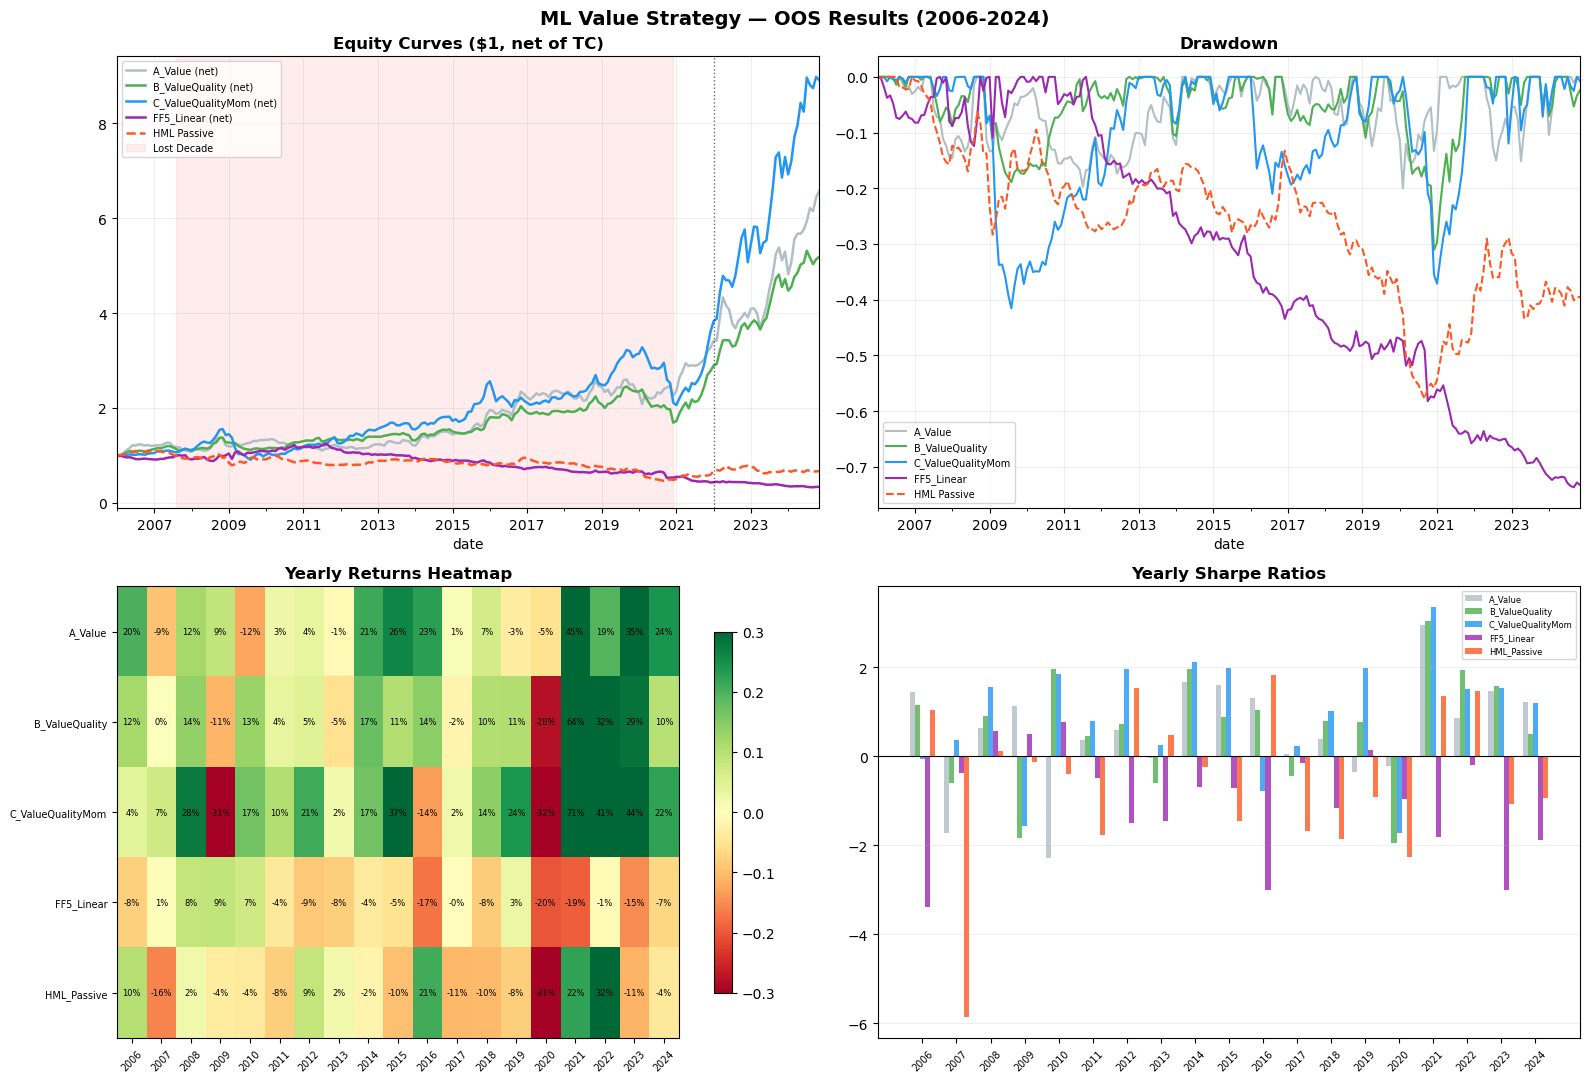


ALL DONE
Output files:
  master_allocation.csv
  yearly_returns.csv
  yearly_sharpe.csv
  ml_value_results.png


In [24]:

# ============================================================
# STEP 17: PLOTS
# ============================================================

colors_strat = {
    'A_Value':           '#B0BEC5',
    'B_ValueQuality':    '#4CAF50',
    'C_ValueQualityMom': '#2196F3',
    'FF5_Linear':        '#9C27B0',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('ML Value Strategy — OOS Results (2006-2024)',
             fontsize=14, fontweight='bold')

# Equity curves
ax = axes[0,0]
for name, port in portfolios.items():
    (1 + port['ls_ret']).cumprod().plot(
        ax=ax, label=f"{name} (net)",
        color=colors_strat.get(name,'#999'), lw=1.8)
(1 + hml.reindex(portfolios['A_Value'].index).dropna()).cumprod().plot(
    ax=ax, label='HML Passive', color='#FF5722', lw=1.8, ls='--')
ax.axvspan(pd.Timestamp('2007-08-01'), pd.Timestamp('2020-12-01'),
           alpha=0.07, color='red', label='Lost Decade')
ax.axvline(pd.Timestamp('2022-01-01'), color='black', lw=1, ls=':', alpha=0.6)
ax.set_title('Equity Curves ($1, net of TC)', fontweight='bold')
ax.legend(fontsize=7); ax.grid(alpha=0.2)

# Drawdown
ax = axes[0,1]
for name, port in portfolios.items():
    cum = (1 + port['ls_ret']).cumprod()
    ((cum - cum.cummax()) / cum.cummax()).plot(
        ax=ax, label=name, color=colors_strat.get(name,'#999'), lw=1.5)
hml_s = hml.reindex(portfolios['A_Value'].index).dropna()
cum_h = (1 + hml_s).cumprod()
((cum_h - cum_h.cummax()) / cum_h.cummax()).plot(
    ax=ax, label='HML Passive', color='#FF5722', lw=1.5, ls='--')
ax.set_title('Drawdown', fontweight='bold')
ax.legend(fontsize=7); ax.grid(alpha=0.2)

# Yearly returns heatmap
ax = axes[1,0]
plot_cols = [c for c in ['A_Value','B_ValueQuality','C_ValueQualityMom',
                          'FF5_Linear','HML_Passive'] if c in yearly_return.columns]
yr_plot = yearly_return[plot_cols].dropna(how='all')
im = ax.imshow(yr_plot.T.values, aspect='auto', cmap='RdYlGn', vmin=-0.3, vmax=0.3)
ax.set_xticks(range(len(yr_plot.index)))
ax.set_xticklabels(yr_plot.index, rotation=45, fontsize=7)
ax.set_yticks(range(len(plot_cols))); ax.set_yticklabels(plot_cols, fontsize=7)
for i in range(len(plot_cols)):
    for j in range(len(yr_plot.index)):
        val = yr_plot.iloc[j,i]
        if pd.notna(val):
            ax.text(j, i, f"{val:.0%}", ha='center', va='center',
                    fontsize=6, color='black')
ax.set_title('Yearly Returns Heatmap', fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)

# Yearly Sharpe bars
ax = axes[1,1]
x = np.arange(len(yearly_sharpe.index))
w = 0.15
for i, col in enumerate(plot_cols):
    if col in yearly_sharpe.columns:
        ax.bar(x + i*w, yearly_sharpe[col].reindex(yearly_sharpe.index).fillna(0),
               w, label=col, color=colors_strat.get(col,'#FF5722'), alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x + w*2)
ax.set_xticklabels(yearly_sharpe.index, rotation=45, fontsize=7)
ax.set_title('Yearly Sharpe Ratios', fontweight='bold')
ax.legend(fontsize=6); ax.grid(alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('ml_value_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("ALL DONE")
print("="*70)
print("Output files:")
for f in ['master_allocation.csv', 'yearly_returns.csv',
          'yearly_sharpe.csv', 'ml_value_results.png']:
    print(f"  {f}")